In [1]:
# Importing relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

### Reading the Data

In [2]:

# "all_CAR.csv" is assumed to be a dataset containing all CAR data, processed through Krish's "CAR_data_import_code.ipynb" code 
 
df_main = pd.read_csv("all_CAR.csv", usecols=lambda c: c != "Unnamed: 0")

### Data Filtering / Time delta

In [3]:
# converting times into the right format
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y-%m-%d %H:%M:%S")  
)

# Creating a new column 'hour' as it will be useful to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour


# --- 1) FILTER ROWS ---------------------------------------------------------

# Define the three conditions

# Rows that represent a particular menu
cond1 = (
    df_main['EP Name'].notna() &
    df_main['Flow Name'].isna() &
    df_main['Activity Name'].isna()
)

# Rows that represent the beginning / end of a call journey
cond2 = (
    df_main['EP Name'].notna() &
    df_main['Activity Name'].notna() &
    df_main['Flow Name'].isna()
)

# rows that represent presence within a queue
cond3 = df_main['Queue Name'].notna()

# Keep rows that satisfy ANY of the three conditions
df_filt = df_main[cond1 | cond2 | cond3].copy()

# --- 2) TIME DELTA (seconds since previous row within each Contact Session ID) -- 

# Ensure timestamp is datetime (safe if it's already datetime64[ns])
df_filt['Activity Start Timestamp'] = pd.to_datetime(df_filt['Activity Start Timestamp'], errors='coerce')

# Sort so "previous row" is truly the prior event in time for that session
# df_filt = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# Compute per-session time difference (first row per session will be NaN)
df_filt['seconds_since_prev'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .diff()
           .dt.total_seconds()
)

# b) seconds until next row (last row per session -> NaN)
df_filt['seconds_until_next'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .shift(-1)
           .sub(df_filt['Activity Start Timestamp'])
           .dt.total_seconds()
)

# df_filt now has the filtered rows plus the new 'seconds_since_prev' columnv

# Keep only rows where both times are >= 0. Not sure why there are such observations. 
df_filt = df_filt[(df_filt["seconds_since_prev"] >= 0) & (df_filt["seconds_until_next"] >= 0)]  



### Creating new columns

1. **menu_repeats**: how many times the same menu appears consecutively (excluding the first). This indicates revisiting the prompt
2. **run_total_seconds**: total time spent in that consecutive menu run.



In [4]:

# sort to ensure correct ordering within each call
df_new = df_filt.copy() 
df_new= df_new.sort_values(["Contact Session ID", "Activity Start Timestamp"]).copy()

# only get activity names that are not null
mask_valid = df_new["Activity Name"].notna()

# identify where a new run begins
    # marks the start of a new consecutive menu run whenever the call changes, the menu changes, or the activity name is missing.
new_run = (
    (df_new["Contact Session ID"] != df_new["Contact Session ID"].shift()) |
    (df_new["Activity Name"] != df_new["Activity Name"].shift()) |
    (~mask_valid)
)   

# assign run IDs
run_id = new_run.cumsum()

# compute run sizes (number of times the same menu has occurred within the run) 
run_sizes = df_new.groupby(run_id, sort=False)["Activity Name"].transform("size")

# apply repeats only to valid activities, set 0 for NaN
df_new["menu_repeats"] = (
    (run_sizes - 1).where(mask_valid, 0).clip(lower=0)    # -1 since we want number of repeats (1 being repeated once)
)

# sum seconds_until_next within each run
df_new["run_total_seconds"] = df_new.groupby(run_id)["seconds_until_next"].transform("sum")

# add run ID to the DataFrame
df_new["run_id"] = run_id




## Analyzing redundant time for the following prompts: 

- MainMenu
- LegalMenu2
- FamilyMenu
- TenantMenu
- BenefitsMenu
- ImmigrationMenu
- EmploymentMenu

We consider only those who have heard the full prompt

In [ ]:

# mapping each Activity name with the corresponding prompt length (English for now)
prompt_length_map = {'MainMenu': 56, 
                     'LegalMenu2': 129, 
                     'FamilyMenu': 45,
                     'TenantMenu': 32, 
                     'BenefitsMenu': 45, 
                     'ImmigrationMenu': 51, 
                     'EmploymentMenu': 27
                     }

# create a new column 'prompt_length' using the mapping dictionary
df_new['prompt_length'] = df_new['Activity Name'].map(prompt_length_map)

# create a new column 'redundant time' as we defined 
df_new['redundant_time'] = df_new['run_total_seconds'] - df_new['prompt_length']

# now subset the data for only those people who listen to the full prompt 
    # since redundant time is Nan for those outside the 7 prompts we chose, this df also includes only the 7 prompts. 
df_full_listeners = df_new[df_new['redundant_time'] >= 0]    # give a little buffer for timing noise
df_full_listeners['redundant_ratio'] = df_full_listeners['run_total_seconds'] / df_full_listeners['prompt_length'] 


### Visualizations

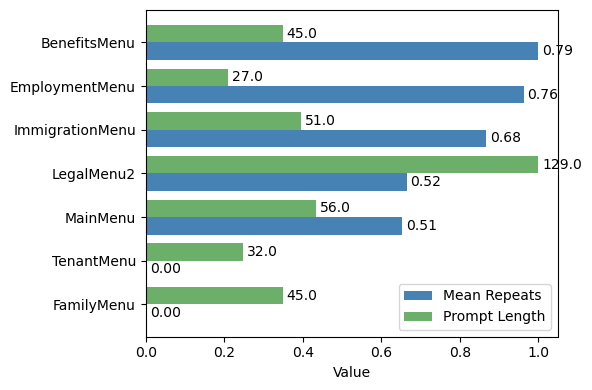

In [18]:
# MEAN REPEATS (without outliers)

# Filter out outliers: keep rows with menu_repeats <= 3
df_filtered = df_full_listeners[df_full_listeners['menu_repeats'] <= 3]

# Prepare summary: mean repeats and prompt length
summary_repeats_length = df_filtered.groupby('Activity Name').agg(
    mean_repeats=('menu_repeats', 'mean'),
    prompt_length=('prompt_length', 'first')  # same for all rows per activity
).reset_index()

# Sort descending by mean repeats
summary_repeats_length = summary_repeats_length.sort_values('mean_repeats', ascending=True).reset_index(drop=True)

# Normalize both columns
summary_repeats_length['mean_repeats_norm'] = summary_repeats_length['mean_repeats'] / summary_repeats_length['mean_repeats'].max()
summary_repeats_length['prompt_length_norm'] = summary_repeats_length['prompt_length'] / summary_repeats_length['prompt_length'].max()

# Bar positions
y_pos = np.arange(len(summary_repeats_length))
bar_width = 0.4

plt.figure(figsize=(6,4))

# Plot normalized mean repeats
plt.barh(y_pos - bar_width/2, summary_repeats_length['mean_repeats_norm'], 
         height=bar_width, color='#4682B4', label='Mean Repeats')

# Plot normalized prompt length
plt.barh(y_pos + bar_width/2, summary_repeats_length['prompt_length_norm'], 
         height=bar_width, color='#6BAF6A', label='Prompt Length')

# Add labels for original values
for i, row in summary_repeats_length.iterrows():
    plt.text(row['mean_repeats_norm'] + 0.01, i - bar_width/2, f"{row['mean_repeats']:.2f}", va='center', color='black')
    plt.text(row['prompt_length_norm'] + 0.01, i + bar_width/2, f"{row['prompt_length']}", va='center', color='black')

# Y-axis
plt.yticks(y_pos, summary_repeats_length['Activity Name'])
plt.xlabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


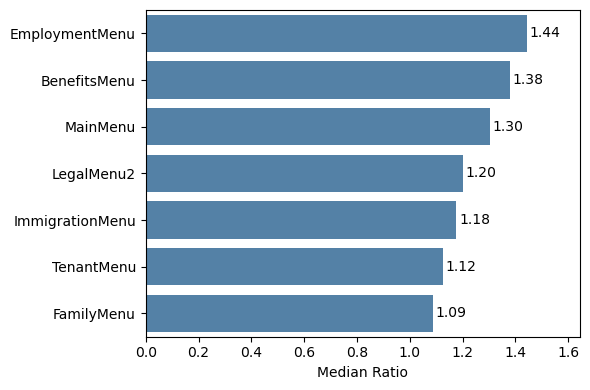

In [12]:
# Median Redundancy Ratio 
summary_counts_ratio = df_full_listeners.groupby('Activity Name').agg(
    median_ratio=('redundant_ratio', 'median')
).reset_index()

summary_counts_ratio = summary_counts_ratio.sort_values('median_ratio', ascending=False).reset_index(drop=True)

plt.figure(figsize=(6,4))

barplot = sns.barplot(
    x='median_ratio',
    y='Activity Name',
    data=summary_counts_ratio,
    color = '#4682B4'
)

# Add labels: median ratio values at the end of each bar
for i, row in summary_counts_ratio.iterrows():
    barplot.text(
        row['median_ratio'] + 0.01,  # offset slightly to the right of bar
        i,                           # y-position corresponds to bar
        f"{row['median_ratio']:.2f}", # format number with 2 decimals
        color='black',
        va='center'
    )

plt.xlabel("Median Ratio")
plt.ylabel("")
plt.xlim(0, summary_counts_ratio['median_ratio'].max() + 0.2)
plt.tight_layout()
plt.show()
